<!--
Notebook Display Styling

This CSS block standardizes the visual presentation of the notebook when rendered in Jupyter.

Changes applied:

1. Body Text Formatting
   - Sets a consistent font size (15px)
   - Improves readability with increased line spacing (1.6)
   - Ensures uniform text appearance across markdown cells

2. Clear Heading Hierarchy
   - H1 enlarged for main section titles
   - H2 slightly smaller for major subsections
   - H3 for detailed subsections

This improves:
- Visual consistency
- Professional presentation
- Readability in exported HTML reports
-->

<style>
/* Standardize body text formatting */
.jp-RenderedHTMLCommon {
    font-size: 15px;
    line-height: 1.6;
}

/* Improve heading hierarchy clarity */
.jp-RenderedHTMLCommon h1 { font-size: 1.9em; }
.jp-RenderedHTMLCommon h2 { font-size: 1.6em; }
.jp-RenderedHTMLCommon h3 { font-size: 1.3em; }
</style>


# Credit Card Fraud Detection

## 1. 📌 Project Overview
This project explores patterns in credit card transaction data to identify potential indicators of fraudulent behavior. The workflow follows an industry-standard data science pipeline, including data cleaning, feature engineering, exploratory analysis, and predictive modeling.


Special attention is paid to avoiding data leakage and ensuring feature generalizability.

### 📊 Dataset Description:

This is a simulated credit card transaction dataset containing legitimate and fraud transactions from the duration Jan 1st 2019 - Dec 31st 2020. It covers credit cards of 1000 customers doing transactions with a pool and 800 merchants. Each row represents a single credit card transaction enriched with temporal, geographic, and demographic attributes.

The dataset includes:

- Transaction details (transaction amount, transaction category, transaction timestamp)

- Temporal features (hour of transaction, day of week, weekend and nighttime indicators)

- Geographic information (customer location, merchant location, and derived transaction distance)

- Customer demographic attributes (age, gender, occupation, city population, state)

- Behavioral indicators (transaction timing patterns, distance anomalies between customer and merchant)

- Fraud label (binary indicators identifying fraudulent transactions)

The project consists of two separate datasets:

- Training dataset (fraudTrain.csv)

- Testing dataset (fraudTest.csv)

Both datasets share identical schema and variable names, enabling a clean and consistent machine learning pipeline. The testing dataset is reserved for out-of-sample evaluation only and is never used during model training or feature learning.

### 🎯 Objective
The primary objectives of this project are:

- 🧹 Clean and preprocess the transaction dataset, including handling categorical variables, transforming temporal and geographic features, and removing irrelevant or high-risk fields

- 📊 Explore and visualize transaction patterns associated with fraudulent behavior through targeted exploratory data analysis (EDA)

- 🧠 Build and compare classification models for fraud detection (e.g., logistic regression, decision trees, and ensemble methods)

- ⚖️ Address class imbalance inherent in fraud data using techniques such as class weighting or resampling methods

- 📈 Evaluate model performance using appropriate metrics, including precision, recall, F1-score, and confusion matrix, with an emphasis on fraud detection effectiveness

- 🔍 Identify key features and behavioral patterns that contribute to higher fraud risk

- 🔁 Develop a fully reusable preprocessing and modeling pipeline

All feature engineering, transformation, and model training are performed exclusively on the training dataset. The finalized pipeline is then applied unchanged to the testing dataset, ensuring a realistic evaluation setup and eliminating data leakage.

### 📂 Data Source

This dataset was obtained from the [Credit Card Transactions Fraud Detection Dataset](https://www.kaggle.com/datasets/kartik2112/fraud-detection/data).  

#### Load Files

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay,
    f1_score, recall_score, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
fraudTest = pd.read_csv('../../../Data/fraudTest.csv')
fraudTrain = pd.read_csv('../../../Data/fraudTrain.csv')

In [3]:
fraudTrainC = fraudTrain.copy()
fraudTrainC.head(3)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


In [4]:
fraudTrainC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

#### 📌 Train Dataset Workflow Plan (`fraudTrain.csv`)

This document outlines an **industrial-grade, leakage-safe workflow** for processing and modeling the training dataset (`fraudTrain.csv`).  
All preprocessing rules, feature engineering decisions, and model fitting steps are **learned exclusively from the training data** and later applied unchanged to the test dataset.

---

#### 0. Scope and Objective

- **Objective:**  
  Build a fraud detection model using historical transaction data while avoiding data leakage.
- **Dataset:**  
  `fraudTrain.csv` (transaction-level data)
- **Key Principle:**  
  - No artificial merging of train and test  
  - All `.fit()` operations occur on the training dataset only

---

#### 1. Load Training Data

- Load `fraudTrain.csv` into memory.
- Verify:
  - Number of rows and columns
  - Column names and data types
  - Basic sanity of the dataset

**Deliverables:**
- Dataset shape
- First few rows
- Schema (`info()` output)

---

#### 2. Data Quality and Sanity Checks (Train Only)

- Check missing values by column (percentage).
- Identify duplicate rows if any.
- Inspect basic statistics:
  - Transaction amount (`amt`)
  - Target variable distribution (`is_fraud`)

**Deliverables:**
- Missing value summary
- Fraud rate in training data

---

#### 3. Define Target and Feature Boundary

- Set target variable:
  - `y_train = is_fraud`
- Separate features from the target.
- Identify columns that are:
  - Pure identifiers
  - Personally identifiable information (PII)
  - Candidates for feature engineering
  - Core predictive features

---

#### 4. Column Cleaning Decisions

##### 4.1 Drop Columns Immediately

Remove fields that do not contribute to prediction or may cause leakage:

- `index` (row index)
- `trans_num` (unique transaction identifier)
- `first`, `last` (PII)
- `zip` (high-cardinality noisy location)
- `merchant` (high-cardinality; excluded in baseline model)

---

##### 4.2 Transform Then Drop Raw Fields

- **Transaction timestamp**
  - Source: `trans_date_trans_time`
  - Derived features:
    - `hour`
    - `dayofweek`
    - `month`
    - `is_weekend`
  - Drop raw timestamp after transformation.

- **Date of birth**
  - Source: `dob`
  - Derived feature:
    - `age` at transaction time
  - Drop `dob` after transformation.

---

##### 4.3 Keep for Feature Engineering Only

These fields are **not used directly as model inputs**:

- `cc_num`
  - Used for user-level aggregation and behavior features.
- `unix_time`
  - Used to compute time-gap features between transactions.

---

##### 4.4 Core Features to Retain

- `amt` (and derived `amt_log`)
- `category`
- `city_pop`
- `state` (optional)
- Geographic coordinates (for distance computation):
  - `lat`, `long`
  - `merch_lat`, `merch_long`

---

#### 5. Feature Engineering Plan (Train Only)

##### 5.1 Time-Based Features

Derived from transaction timestamp:

- Hour of day
- Day of week
- Month
- Weekend indicator

---

##### 5.2 Amount-Based Features

- Log transformation:
  - `amt_log = log1p(amt)`
- (Optional) User-relative amount features based on training data only.

---

##### 5.3 Geographic Distance Feature

- Compute distance between:
  - Customer location (`lat`, `long`)
  - Merchant location (`merch_lat`, `merch_long`)
- Resulting feature:
  - `distance_km`
- Drop raw latitude and longitude columns after distance calculation (optional).

---

##### 5.4 Optional User Behavioral Aggregates (Advanced)

Using `cc_num` within training data:

- Transaction count per user
- Average and median transaction amount
- Average transaction distance
- Time gap between consecutive transactions

> All aggregates must be computed **only from training data** and later applied to test data using the same logic.

---

#### 6. Preprocessing Pipeline Definition

- Identify:
  - Numerical feature columns
  - Categorical feature columns
- Preprocessing steps:
  - Numerical:
    - Median imputation
  - Categorical:
    - Most-frequent imputation
    - One-hot encoding (`handle_unknown="ignore"`)
- Use `ColumnTransformer` within an sklearn `Pipeline`.

**Leakage Rule:**  
All preprocessing `.fit()` operations occur on training data only.

---

#### 7. Model Training Strategy

- Baseline model:
  - Logistic Regression with class weighting
- Optional models:
  - Random Forest
  - Gradient Boosting
  - XGBoost (if applicable)

Purpose:
- Establish a strong, interpretable baseline before moving to complex models.

---

#### 8. Validation and Evaluation (Train Phase)

Given severe class imbalance:

- Avoid relying on accuracy alone.
- Primary evaluation metrics:
  - Precision
  - Recall
  - F1-score
  - PR-AUC (Average Precision)

Validation approaches:
- Stratified K-Fold cross-validation (train only)
- Optional time-based split within training data

---

#### 9. Threshold Selection (Business-Oriented)

- Evaluate multiple decision thresholds.
- Select threshold based on:
  - Recall requirements
  - Precision constraints
- Document trade-offs clearly.

---

#### 10. Model Interpretability

- Identify top fraud risk drivers:
  - Coefficients (linear models)
  - Feature importance (tree models)
- Optional:
  - SHAP analysis for model explanations

**Deliverable:**
- Ranked list of transaction-level risk factors.

---

#### 11. Save Artifacts for Reuse

Persist the following for later application to test data:

- Trained preprocessing + model pipeline
- Selected classification threshold
- Evaluation metrics
- Key plots (PR curve, confusion matrix)

Suggested directories:
- `models/`
- `outputs/figures/`
- `outputs/metrics/`

---

#### 12. Application to Test Dataset (Next Phase)

- Load `fraudTest.csv` separately.
- Apply **the same feature engineering and preprocessing pipeline**.
- Use `.transform()` and `.predict()` only.
- Evaluate final model performance on test data.

> This guarantees a leakage-free, forward-looking evaluation consistent with real-world fraud detection systems.


#### 🧪 Schema & Data Quality Checks

In [5]:
fraudTrainC.isna().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [94]:
fraudTrainC.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


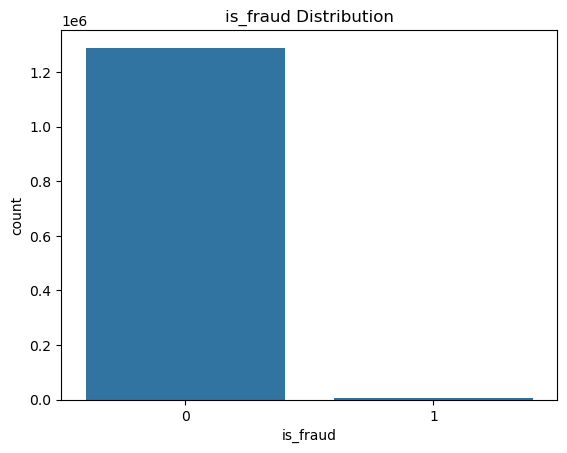

is_fraud
0    99.42%
1     0.58%
Name: proportion, dtype: object

In [95]:
# is_fraud distribution (training set only)
sns.countplot(x='is_fraud', data=fraudTrainC)
plt.title("is_fraud Distribution")
plt.show()

( fraudTrainC['is_fraud'].value_counts(normalize=True) * 100 ).map('{:.2f}%'.format)

#### Dataset Overview

In [96]:
fraudTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [97]:
fraudTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

## 2. 🧹 Data Processing

### Feature Selection Rationale

Certain raw fields are excluded from modeling due to high cardinality, lack of behavioral meaning, or privacy concerns.

- Identifiers (e.g., transaction ID, index columns) are removed as they do not carry predictive information.
- Raw datetime and location fields are replaced with derived behavioral features.
- Personally identifiable information (PII) is dropped after feature extraction.

These decisions help reduce noise, prevent overfitting, and improve model generalizability.


| Feature Type | Examples | Action |
|-------------|---------|--------|
| Identifiers | trans_num, index | Dropped |
| Time fields | trans_date_trans_time | Transformed |
| Demographics | dob | Derived (age), then dropped |
| Location | lat / long | To be transformed into distance |


In [98]:
# Remove fields that do not contribute to prediction or may cause leakage:
drop_cols = [
    "Unnamed: 0", "merchant", "first", "last", "street", "zip", "trans_num"
]

In [99]:
fraudTrainC = fraudTrainC.drop(columns=drop_cols)
fraudTrainC.head()

,trans_date_trans_time,cc_num,category,amt,gender,city,state,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,1939,Patent attorney,1967-01-12,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,misc_pos,41.96,M,Doe Hill,VA,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,1325376186,38.674999,-78.632459,0


## 3. 🛠️ Feature Engineering

### 3.1 🚀 Transaction Speed

### Definition

Transaction speed measures how quickly a credit card is used across geographic locations by combining spatial distance with the elapsed time between consecutive transactions.

This feature captures spatial deviations from a cardholder’s typical purchasing region, which may indicate unauthorized usage.

$$
\text{Transaction Speed (km/h)} = 
\frac{\text{Transaction Distance (km)}}{\text{Time Gap (hours)}}
$$

Where:

- **Transaction Distance** is calculated using the **Haversine formula**, which estimates the great-circle distance between customer and merchant locations on the Earth's surface.
- **Time Gap** represents the time elapsed since the previous transaction for the same credit card.

---

### Why Use the Haversine Formula?

Latitude and longitude coordinates lie on a spherical surface rather than a flat plane. The Haversine formula accounts for the Earth's curvature, providing a more accurate estimate of real-world travel distance compared to simple Euclidean calculations.

Transforming raw geographic coordinates into distance helps capture **spatial anomalies**, while combining distance with time enables the detection of **physically implausible travel patterns** — a strong indicator of potential fraudulent activity.

---

### Is This a Problem?

It depends on the model type:

- For Linear Models (e.g., Logistic Regression):
❌ This can be problematic due to unstable coefficients and sensitivity to correlated features.
- For Tree-Based Models (e.g., XGBoost, Random Forest, CatBoost):
✅ This is generally not an issue

---

### Tree-based models:

Do not rely on linear relationships
Do not require feature independence
Automatically select the most informative feature splits

As a result, the model can internally choose between:

Distance-based signals
Time-based signals
Speed-based signals

depending on which provides the strongest predictive power.

---

### Objective of This Feature

The goal of constructing the transaction speed feature is to identify abnormal behavioral patterns. Transactions occurring at unrealistically high speeds may suggest compromised cards, account takeover, or unauthorized usage.

After deriving this feature, the original coordinate variables are removed to reduce redundancy and prevent multicollinearity in the modeling stage.

**Example:**
Ordered a cup of coffee at a Starbucks in NYC vs Shopping in Toyko 3 hours later ---> fraud signal

In [100]:
def haversine_vectorized(lat1, lon1, lat2, lon2, radius_km=6371.0):
    """
    Vectorized Haversine distance
    Accepts scalars/NumPy arrays/pandas Series and return distances in km
    """

    # Convert inputs to numpy arrays (handles pandas Series too)
    lat1 = np.array(lat1, dtype="float64")
    lon1 = np.array(lon1, dtype="float64")
    lat2 = np.array(lat2, dtype="float64")
    lon2 = np.array(lon2, dtype="float64")

    # Convert degrees -> radians (trig functions expect radians)
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    # Compute deltas (difference between points)
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine "a" term (half-versed-sine based)
    a = (
        np.sin(dlat/2)**2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    )

    # Central angle c (theta in radians)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))

    # Arc length on sphere = radius * angle
    return radius_km * c

def add_distance_feature(df, lat_col="lat", lon_col="long",
                        merch_lat_col="merch_lat", merch_lon_col="merch_long",
                        out_col="txn_distance_km"):
    """
    Adds a transaction distance feature to df and returns df.
    Designed to be reusable on both train and test.
    """

    # Compute distance using the vectorized haversine function
    df[out_col] = haversine_vectorized(
        df[lat_col],
        df[lon_col],
        df[merch_lat_col],
        df[merch_lon_col]
    )

    return df

In [101]:
def add_time_features(df, dt_col="trans_date_trans_time"):
    
    dt = pd.to_datetime(df[dt_col])
    
    df["hour"] = dt.dt.hour
    df['dayofweek'] = dt.dt.dayofweek # Mon=0
    df['month'] = dt.dt.month
    
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_night'] = ((df['hour'] <= 5) | (df['hour'] >= 22)).astype(int)
    
    # Cyclical encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    return df

In [102]:
def add_time_gap_and_speed(
    df,
    id_col='cc_num',
    time_col='unix_time',
    dist_col='txn_distance_km',
    speed_clip_upper=None
):

    df = df.copy()
    df = df.sort_values([id_col, time_col])
    
    df['time_gap_sec'] = df.groupby(id_col)[time_col].diff()
    df['time_gap_hr'] = df["time_gap_sec"] / 3600
    
    # avoid divide-by-zero / extreme vals
    # Series.clip(lower=minimum, upper=maximum)
    gap_hr = df['time_gap_hr'].clip(lower=1/3600) # at least 1 sec
    df['txn_speed_kmh'] = df[dist_col] / gap_hr

    if speed_clip_upper is None:
        speed_clip_upper = df['txn_speed_kmh'].quantile(0.99)
    
    df['txn_speed_kmh_clip'] = df['txn_speed_kmh'].clip(upper=speed_clip_upper)
    
    # # optional: log transforms
    # df['time_gap_log'] = np.log1p(df['time_gap_sec'].clip(lower=0)) # log val cannot be negative
    # # df['speed_log'] = np.log1p(df['txn_speed_kmh'].clip(lower=0))
    # df['city_pop_log'] = np.log1p(df['city_pop']).clip(lower=0)

    return df, speed_clip_upper

def add_log_features(
    df,
    time_gap_col='time_gap_sec',
    city_pop_col='city_pop'
):

    df = df.copy()
    # optional: log transforms
    df['time_gap_log'] = np.log1p(df[time_gap_col].clip(lower=0)) # log val cannot be negative
    # df['speed_log'] = np.log1p(df['txn_speed_kmh'].clip(lower=0))
    df['city_pop_log'] = np.log1p(df[city_pop_col]).clip(lower=0)

    return df

In [103]:
fraudTrainC = fraudTrain.copy()

fraudTrainC = add_distance_feature(fraudTrainC)
fraudTrainC = add_time_features(fraudTrainC)
fraudTrainC, speed_clip_upper = add_time_gap_and_speed(fraudTrainC)
fraudTrainC = add_log_features(fraudTrainC)

In [104]:
fraudTrainC['txn_speed_kmh'].quantile([.99, .995, .999, 1.0])

0.990      1445.219986
0.995      2887.674899
0.999     14317.256709
1.000    457542.341306
Name: txn_speed_kmh, dtype: float64

In [105]:
fraudTrainC['txn_speed_kmh_clip'].quantile([.99, .995, .999, 1.0])

0.990    1445.213477
0.995    1445.219986
0.999    1445.219986
1.000    1445.219986
Name: txn_speed_kmh_clip, dtype: float64

In [106]:
fraudTrainC["txn_speed_kmh"].max(), fraudTrainC["txn_speed_kmh_clip"].max()

(457542.34130633867, 1445.2199858986924)

### 3.2 Demographic Features
- Age calculation

In [107]:
# ----------------------------------
# Demographic Feature
# ----------------------------------

def demo_feature(
    df,
    dob_col='dob',
    date_time_col='trans_date_trans_time'
):

    df = df.copy()
    
    # Convert to datetime - 'dob'
    df['dob'] = pd.to_datetime(df[dob_col])
    df['trans_date_trans_time'] = pd.to_datetime(df[date_time_col])

    # Extract time-based features - 'dob'
    # Calculate age difference between the transaction timestamp and the customer's dob
    # If the transaction occurred before the person’s birthday in that year, subtract one from the age; otherwise (after dob), the age remains unchanged.
    # (trans_month) < (birth_month) or (trans_month == birth_month) & (trans_day < birth_day)
    t = df['trans_date_trans_time']
    b = df['dob']

    before_bday = (t.dt.month < b.dt.month) | ((t.dt.month == b.dt.month) & (t.dt.day < b.dt.day))

    df['age'] = (t.dt.year - b.dt.year) - before_bday.astype(int)

    return df

In [108]:
fraudTrainC = demo_feature(fraudTrainC)
fraudTrainC.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 1017 to 1296427
Data columns (total 40 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Unnamed: 0             1296675 non-null  int64         
 1   trans_date_trans_time  1296675 non-null  datetime64[ns]
 2   cc_num                 1296675 non-null  int64         
 3   merchant               1296675 non-null  object        
 4   category               1296675 non-null  object        
 5   amt                    1296675 non-null  float64       
 6   first                  1296675 non-null  object        
 7   last                   1296675 non-null  object        
 8   gender                 1296675 non-null  object        
 9   street                 1296675 non-null  object        
 10  city                   1296675 non-null  object        
 11  state                  1296675 non-null  object        
 12  zip                    1296675

### Cardinality Assessment

Categorical features were first evaluated based on the number of unique levels.

Low-cardinality variables (e.g., gender) were considered suitable for one-hot encoding, while high-cardinality variables (e.g., city, job) required alternative encoding strategies.

In [109]:
print(fraudTrainC['city'].nunique(), "\n")
print(fraudTrainC['job'].nunique(), "\n")
print(fraudTrainC['category'].nunique(), "\n")

894 

494 

14 



# Job Group Classification Categories

This document defines the industry classification structure used to group job titles into structured `job_group` categories via regex pattern matching.

---

## 1. insurance

**Description:**  
Insurance industry professionals involved in underwriting, claims, actuarial science, and risk assessment.

**Includes:**
- insurance
- underwriter
- actuary / actuarial
- claims / claims adjuster
- broker
- loss adjuster
- adjuster
- risk analyst

---

## 2. legal_practice

**Description:**  
Legal professionals working in law firms or practicing law directly.

**Includes:**
- attorney
- lawyer
- solicitor
- barrister
- paralegal
- patent attorney
- trademark attorney
- chartered legal executive
- licensed conveyancer

---

## 3. compliance_regulatory

**Description:**  
Corporate or governmental regulatory and compliance professionals.

**Includes:**
- compliance
- regulatory
- regulatory affairs
- trading standards officer

---

## 4. healthcare_clinical

**Description:**  
Medical and healthcare practitioners.

**Includes:**
- doctor / physician
- surgeon
- nurse / midwife
- pharmacist
- paramedic
- radiographer
- therapist
- psychologist / psychiatrist
- physiotherapist
- chiropractor
- osteopath
- optometrist / optician
- podiatrist
- pathologist
- oncologist
- immunologist
- acupuncturist
- homeopath
- pharmacologist
- medical technical officer
- phytotherapist
- health visitor
- health service manager
- health promotion specialist

---

## 5. software_it

**Description:**  
Technology and software professionals.

**Includes:**
- IT
- software
- developer
- programmer
- systems analyst
- systems engineer
- network
- database
- telecommunications
- information systems
- data scientist
- machine learning
- AI
- cyber security
- intelligence analyst
- information officer

---

## 6. engineering

**Description:**  
Engineering and applied technical professions.

**Includes:**
- engineer
- mechanical / electrical / civil / structural engineer
- aeronautical
- petroleum
- mining
- manufacturing
- metallurgist
- materials engineer
- process technologist
- engineering technologist
- textile technologist
- clothing/textile technologist
- colour technologist
- architectural technologist
- quarry manager
- mudlogger

---

## 7. construction_realestate_architecture

**Description:**  
Construction and built-environment professions.

**Includes:**
- architect
- quantity surveyor
- building surveyor
- surveyor
- contractor
- site engineer
- town planner
- urban planner
- planner

---

## 8. finance_banking_trading

**Description:**  
Financial services and accounting professionals.

**Includes:**
- accountant
- auditor
- tax professional
- controller / comptroller
- banker
- investment professional
- trader
- financial analyst
- economist
- pensions professional

---

## 9. transportation_aviation

**Description:**  
Air and transport professionals.

**Includes:**
- pilot
- airline staff
- cabin crew
- aviation professional
- air traffic controller

---

## 10. social_public_services

**Description:**  
Community and social support professionals.

**Includes:**
- counsellor
- social worker
- community worker
- development worker
- aid worker
- advice worker
- charity officer
- volunteer coordinator
- race relations officer
- interpreter

---

## 11. environmental_natural_resources

**Description:**  
Environmental management and agricultural professionals.

**Includes:**
- conservation
- fisheries
- forestry
- environmental consultant
- environmental manager
- agricultural consultant
- horticulturist
- arboriculturist
- farm manager
- environmental health practitioner

---

## 12. government_public_emergency_military

**Description:**  
Government, law enforcement, and military personnel.

**Includes:**
- police
- firefighter
- immigration officer
- civil service
- government employee
- military / armed forces
- prison officer
- probation officer
- emergency planning
- public affairs
- politician’s assistant

---

## 13. science_research

**Description:**  
Scientific and research professionals.

**Includes:**
- scientist
- researcher
- statistician
- biochemist
- geneticist
- geologist
- hydrologist
- oceanographer
- toxicologist
- chemist
- physicist
- seismologist
- occupational hygienist
- operational researcher
- animal nutritionist
- exercise physiologist
- archaeologist
- cartographer
- animal technologist

---

## 14. education

**Description:**  
Academic and teaching professionals.

**Includes:**
- teacher
- professor
- lecturer
- tutor
- librarian
- academic librarian
- careers adviser
- learning mentor

---

## 15. media_arts_design_entertainment

**Description:**  
Creative and entertainment professionals.

**Includes:**
- designer
- artist
- writer
- editor
- journalist
- producer
- photographer
- film
- television
- animator
- illustrator
- curator
- archivist
- conservator
- museum
- gallery
- theatre
- dancer
- musician
- camera operator
- gaffer
- press sub
- sub editor
- arts development officer
- location manager

---

## 16. marketing_pr_sales

**Description:**  
Marketing and commercial roles.

**Includes:**
- marketing
- sales
- public relations
- advertising
- media planner
- account executive
- merchandiser
- retail
- dealer
- buyer
- bookseller
- market researcher
- event organiser

---

## 17. operations_supplychain_logistics

**Description:**  
Operational and logistics professionals.

**Includes:**
- logistics
- supply chain
- warehouse
- distribution
- freight forwarder
- procurement
- purchasing
- transport planner
- operations manager
- production manager

---

## 18. hospitality_tourism_food

**Description:**  
Hospitality and service industry professionals.

**Includes:**
- hotel staff
- tourism professional
- restaurant staff
- barista
- catering
- travel
- tour manager
- theme park manager
- brewer
- pub staff

---

## 19. hr_admin

**Description:**  
Human resources and administrative professionals.

**Includes:**
- human resources
- HR
- administrator
- admin
- secretary
- legal secretary
- personnel
- records manager
- equality and diversity officer
- training and development

---

## 20. skilled_trades_maintenance

**Description:**  
Manual and trade-based occupations.

**Includes:**
- electrician
- plumber
- mechanic
- maintenance
- repair technician

---

## 21. sports_recreation

**Description:**  
Sports and recreation professionals.

**Includes:**
- sports development officer
- fitness centre manager
- gym manager

---

## 22. business_management

**Description:**  
Senior leadership and management roles.

**Includes:**
- CEO / COO / CTO / CFO
- chief executive officer
- executive director
- chief of staff
- general manager
- project manager
- product manager
- operations manager
- management consultant

---

## 23. missing_or_low_info

**Description:**  
Low-information job titles.

**Includes exactly:**
- sub
- make
- land
- copy
- unknown
- n/a
- na
- none

---

## 24. other_unknown

**Description:**  
Jobs that do not match any defined regex pattern.

### 3.3 Job Industry Encoding
- Regex classification
- Missing_or_low_info handling
  - Transaction Amount Transformation
  - Raw amount distribution
  - Log transform (amt)
  - Variance Comparison Before and After Log Transformation

#### 3.3.1 Regex classification & Raw amount distribution

In [110]:
import re
import numpy as np

ADD_BUSINESS_MANAGEMENT = True

# ==========================================================
# Industry Classification Rules (UPDATED: split legal_compliance)
# ==========================================================

INDUSTRY_PATTERNS = [

    # ------------------------------------------------------
    # Insurance
    # ------------------------------------------------------
    ("insurance",
     r"\b(insurance|underwriter|actuar(?:y|ial)|claims?|broker|"
     r"loss\s*adjust(?:er|or)|adjuster|risk\s*analyst)\b"),

    # ------------------------------------------------------
    # Legal Practice (law firms / attorneys)
    # ------------------------------------------------------
    ("legal_practice",
     r"\b(attorney|lawyer|solicitor|barrister|paralegal|"
     r"(patent|trade\s*mark|trademark)\s+attorney|"
     r"chartered\s+legal\s+executive|licen[cs]ed\s+conveyancer)\b"),

    # ------------------------------------------------------
    # Compliance / Regulatory (corporate / government compliance)
    # ------------------------------------------------------
    ("compliance_regulatory",
     r"\b(compliance|regulatory(\s+affairs)?|trading\s+standards)\b"),

    # ------------------------------------------------------
    # Healthcare / Clinical
    # ------------------------------------------------------
    ("healthcare_clinical",
     r"\b(doctor|physician|surgeon|neurosurgeon|nurse|midwife|pharmacist|"
     r"paramedic|ambulance\s+person|radiograph(?:er|y)|therap(?:ist|y)|"
     r"psycholog(?:ist|y)|psychiatrist|psychotherapist|physiotherapist|"
     r"chiropractor|osteopath|optometrist|orthoptist|optician|podiatrist|"
     r"chiropodist|pathologist|oncologist|immunolog(?:ist|y)|"
     r"acupuncturist|homeopath|health\s+visitor|"
     r"health\s+service\s+manager|health\s+promotion\s+specialist|"
     r"pharmacolog(?:ist|y)|medical\s+technical\s+officer|"
     r"phytotherapist)\b"),

    # ------------------------------------------------------
    # Software / IT
    # ------------------------------------------------------
    ("software_it",
     r"\b(it\b|software|developer|programmer|"
     r"systems?\s+(analyst|developer|engineer)|network|database|"
     r"telecom(?:munications)?|information\s+systems|"
     r"data\s+scientist|machine\s+learning|ai\b|cyber|security|"
     r"intelligence\s+analyst|information\s+officer)\b"),

    # ------------------------------------------------------
    # Engineering (UPDATED with mudlogger)
    # ------------------------------------------------------
    ("engineering",
     r"\b(engineer|engineering|mechanical|electrical|civil|structural|"
     r"aeronautical|petroleum|mining|manufacturing|"
     r"metallurg(?:ist|y)|materials?\s+engineer|"
     r"process\s+technologist|engineering\s+technologist|"
     r"textile\s+technologist|clothing/textile\s+technologist|"
     r"garment/textile\s+technologist|colour\s+technologist|"
     r"architectural\s+technologist|quarry\s+manager|"
     r"mud\s*logger|mudlogger)\b"),

    # ------------------------------------------------------
    # Construction / Real Estate / Architecture
    # ------------------------------------------------------
    ("construction_realestate_architecture",
     r"\b(architect|architecture|quantity\s+surveyor|"
     r"building\s+surveyor|survey(or)?|construction|contractor|"
     r"site\s+engineer|town\s+planner|urban\s+planner|planner)\b"),

    # ------------------------------------------------------
    # Finance / Banking / Trading
    # ------------------------------------------------------
    ("finance_banking_trading",
     r"\b(accountant|auditor|tax|comptroller|controller|banker|"
     r"investment|trader|financial|finance|economist|pensions?)\b"),

    # ------------------------------------------------------
    # Transportation / Aviation
    # ------------------------------------------------------
    ("transportation_aviation",
     r"\b(pilot|airline|cabin\s+crew|flight|aviation|"
     r"air\s+traffic\s+controller)\b"),

    # ------------------------------------------------------
    # Social / Public Services
    # ------------------------------------------------------
    ("social_public_services",
     r"\b(counsellor|counselor|social\s+worker|community\s+worker|"
     r"community\s+arts\s+worker|community\s+development\s+worker|"
     r"development\s+worker|aid\s+worker|advice\s+worker|"
     r"charity(\s+officer)?|volunteer\s+coordinator|"
     r"race\s+relations(\s+officer)?|interpreter)\b"),

    # ------------------------------------------------------
    # Environmental / Natural Resources (UPDATED)
    # ------------------------------------------------------
    ("environmental_natural_resources",
     r"\b(conservation|nature\s+conservation|fisheries|heritage|"
     r"forestry|woodland|waste\s+management|energy\s+manager|"
     r"environmental\s+consultant|environmental\s+manager|"
     r"agricultural\s+consultant|horticultur(?:ist|al)|"
     r"arboriculturist|farm\s+manager|"
     r"amenity\s+horticulturist|commercial\s+horticulturist|"
     r"environmental\s+health\s+practitioner)\b"),

    # ------------------------------------------------------
    # Government / Public / Military
    # ------------------------------------------------------
    ("government_public_emergency_military",
     r"\b(police|firefighter|immigration|civil\s+service|government|"
     r"military|armed\s+forces|prison\s+officer|probation\s+officer|"
     r"warden|ranger|emergency\s+planning|public\s+affairs|"
     r"politician'?s\s+assistant)\b"),

    # ------------------------------------------------------
    # Science / Research
    # ------------------------------------------------------
    ("science_research",
     r"\b(scientist|research|statistician|biochemist|geneticist|"
     r"cytogeneticist|embryolog(?:ist|y)|ecolog(?:ist|y)|"
     r"geoscientist|geochemist|geolog(?:ist|y)|hydrogeolog(?:ist|y)|"
     r"hydrolog(?:ist|y)|oceanograph(?:er|y)|toxicolog(?:ist|y)|"
     r"chemist|analytical\s+chemist|physicist|"
     r"herpetolog(?:ist|y)|seismolog(?:ist|y)|seismic\s+interpreter|"
     r"field\s+trials?|occupational\s+hygienist|"
     r"operational\s+researcher|animal\s+nutritionist|"
     r"exercise\s+physiologist|herbalist|health\s+and\s+safety\s+adviser|"
     r"social\s+researcher|archaeolog(?:ist|y)|"
     r"cartograph(?:er|y)|animal\s+technologist)\b"),

    # ------------------------------------------------------
    # Education
    # ------------------------------------------------------
    ("education",
     r"\b(teacher|professor|lecturer|tutor|school|education|"
     r"librarian|academic\s+librarian|careers?\s+adviser|"
     r"learning\s+mentor)\b"),

    # ------------------------------------------------------
    # Media / Arts / Entertainment (UPDATED)
    # ------------------------------------------------------
    ("media_arts_design_entertainment",
     r"\b(designer|artist|writer|editor|journalist|producer|"
     r"photograph(?:er|y)|film|television|radio|presenter|broadcast|"
     r"animator|illustrator|curator|archivist|conservator|"
     r"museum|gallery|theatre|dancer|musician|camera\s+operator|"
     r"gaffer|lexicographer|press\s+sub|sub\s*editor|"
     r"arts\s+development\s+officer|location\s+manager)\b"),

    # ------------------------------------------------------
    # Marketing / PR / Sales
    # ------------------------------------------------------
    ("marketing_pr_sales",
     r"\b(marketing|sales|public\s+relations|advertising|"
     r"media\s+planner|account\s+executive|merchandis(?:er|ing)|"
     r"retail|dealer|buyer|bookseller|market\s+researcher|"
     r"event\s+organiser)\b"),

    # ------------------------------------------------------
    # Operations / Supply Chain / Logistics
    # ------------------------------------------------------
    ("operations_supplychain_logistics",
     r"\b(logistics|supply\s*chain|warehouse|distribution|freight|"
     r"freight\s+forwarder|procurement|purchas(?:ing|er)|"
     r"transport\s+planner|operations|production\s+manager)\b"),

    # ------------------------------------------------------
    # Hospitality / Tourism / Food
    # ------------------------------------------------------
    ("hospitality_tourism_food",
     r"\b(hotel|tourism|restaurant|barista|catering|travel|leisure|"
     r"tour\s+manager|theme\s+park\s+manager|tourist\s+information|"
     r"technical\s+brewer|brewer|public\s+house|pub)\b"),

    # ------------------------------------------------------
    # HR / Admin
    # ------------------------------------------------------
    ("hr_admin",
     r"\b(human\s+resources|hr\b|administrator|admin\b|secretary|"
     r"legal\s+secretary|personnel|records\s+manager|"
     r"careers?\s+information\s+officer|"
     r"equality\s+and\s+diversity\s+officer|"
     r"training\s+and\s+development)\b"),

    # ------------------------------------------------------
    # Skilled Trades / Maintenance
    # ------------------------------------------------------
    ("skilled_trades_maintenance",
     r"\b(electrician|plumber|mechanic|maintenance|repair|technician)\b"),

    # ------------------------------------------------------
    # Sports / Recreation
    # ------------------------------------------------------
    ("sports_recreation",
     r"\b(sports\s+development\s+officer|fitness\s+centre\s+manager|"
     r"gym\s+manager)\b"),
]

# ----------------------------------------------------------
# Optional Business Management Insert
# ----------------------------------------------------------
if ADD_BUSINESS_MANAGEMENT:
    INDUSTRY_PATTERNS.insert(11, (
        "business_management",
        r"\b(ceo|coo|cto|cfo|chief\s+(executive|operating|technology|financial)\s+officer|"
        r"chief\s+strategy\s+officer|chief\s+of\s+staff|executive\s+director|"
        r"general\s+manager|(project|product|operations|office|facilities|"
        r"call\s+centre|estate|stage|theatre|heritage)\s+manager|"
        r"management\s+consultant)\b"
    ))

compiled = [(g, re.compile(p, flags=re.I)) for g, p in INDUSTRY_PATTERNS]

# ==========================================================
# Job Group Assignment Function
# ==========================================================
def add_job_group(df, col="job", out_col="job_group"):

    s = (
        df[col]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    group = np.array(["other_unknown"] * len(df), dtype=object)

    # Low info
    low_info_mask = (s == "") | s.isin(
        {"sub", "make", "land", "copy", "unknown", "n/a", "na", "none"}
    )
    group[low_info_mask] = "missing_or_low_info"

    # Regex classification
    for gname, cregex in compiled:
        mask = (group == "other_unknown") & s.str.contains(cregex, na=False)
        group[mask] = gname

    df[out_col] = group
    return df


# ==========================================================
# Apply
# ==========================================================
fraudTrainC = add_job_group(fraudTrainC)
fraudTrainC["job_group"].value_counts()

/var/folders/vl/d4jp3x4n6pvgdsw9fp1v7m6h0000gn/T/ipykernel_3659/1860997588.py:246: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = (group == "other_unknown") & s.str.contains(cregex, na=False)


job_group
media_arts_design_entertainment         183689
healthcare_clinical                     177601
engineering                             157806
science_research                        150764
education                                82323
construction_realestate_architecture     71229
finance_banking_trading                  67642
software_it                              53103
environmental_natural_resources          51373
marketing_pr_sales                       50416
government_public_emergency_military     37452
social_public_services                   33284
business_management                      31657
insurance                                28830
hospitality_tourism_food                 24606
legal_practice                           21997
hr_admin                                 21065
missing_or_low_info                      15406
skilled_trades_maintenance                8209
operations_supplychain_logistics          8126
compliance_regulatory                     7726
tra

#### 3.3.2 Transaction Amount Transformation
- Log Transformation (log1p)
- Variance Stabilization Analysis

In [111]:
missing_or_low_info = (
    fraudTrainC.loc[fraudTrainC['job_group'] == 'missing_or_low_info', 'job']
        .fillna("<<NULL>>")      # 防止真 NaN
        .astype(str)
        .str.strip()
        .str.lower()
        .value_counts()
)

missing_or_low_info.head(30)

job
sub     6701
make    5643
land    2558
copy     504
Name: count, dtype: int64

In [112]:
fraudTrainC.groupby('job_group').amt.var().sort_values(ascending=False)

job_group
legal_practice                          61889.722223
missing_or_low_info                     41805.190078
media_arts_design_entertainment         34159.060519
science_research                        29478.858337
environmental_natural_resources         27524.834300
healthcare_clinical                     27269.755851
operations_supplychain_logistics        27100.220471
hr_admin                                24078.355715
finance_banking_trading                 23527.835135
transportation_aviation                 23357.907751
construction_realestate_architecture    22637.405275
marketing_pr_sales                      22482.940595
business_management                     22260.627237
skilled_trades_maintenance              21548.568954
education                               21075.650739
engineering                             20958.410495
government_public_emergency_military    19110.688781
software_it                             18595.019613
hospitality_tourism_food            

In [113]:
fraudTrainC['amt_log'] = np.log1p(fraudTrainC['amt'])
fraudTrainC.groupby('job_group')['amt_log'].var().sort_values(ascending=False)

job_group
sports_recreation                       1.746454
missing_or_low_info                     1.723151
education                               1.701174
legal_practice                          1.697030
transportation_aviation                 1.696162
software_it                             1.695897
construction_realestate_architecture    1.689447
business_management                     1.688776
finance_banking_trading                 1.686305
healthcare_clinical                     1.683198
science_research                        1.671162
marketing_pr_sales                      1.664454
government_public_emergency_military    1.655761
media_arts_design_entertainment         1.648155
engineering                             1.635775
environmental_natural_resources         1.626027
hospitality_tourism_food                1.602195
skilled_trades_maintenance              1.583083
social_public_services                  1.581555
insurance                               1.579529
hr_admin  

***🔴 Before Log Transformation (Original amt)***
- Variance range:
    - Highest: 6,188 (legal_practice)
    - Lowest: 13,850 (insurance)
- Variance ratio: 61889/13850 = 4.5 x difference
- The data exhibits a clear heavy-tailed distribution

***🟢 After Log Transformation (amt_log)***
- Variance range:
    - Highest: 1.74
    - Lowest: 1.48
- Variance values are now tightly clustered.
- Extreme values no longer dominate the distribution.

The consistently high variance of _***missing_or_low_info***_ before and after log transformation suggests structural dispersion within the category, reflecting intrinsic heterogeneity rather than heavy-tail effects.

### 3.4 Statistical Risk Signal Validation

#### 3.4.1 Risk Signal Mining Using a Lift-Based Screening Pipeline

When analyzing fraud risk by subgroup (e.g., job or job_group), raw fraud rate alone is not sufficient.

We must answer three key questions:

1. Is the subgroup large enough to be statistically stable?
2. Is its fraud rate meaningfully higher than the global average?
3. Is the difference statistically significant?

To answer these consistently, we build a **Lift-based risk screening pipeline**.

---

#### 3.4.2 Global Fraud Baseline

Global average fraud rate:

0.005788651743883394

This serves as the benchmark for subgroup comparisons.

All subgroup risk signals are evaluated relative to this baseline.

---

#### 3.4.3 Definition of Lift

Lift measures how much higher (or lower) a subgroup’s fraud rate is compared to the overall population.

Formula:

Lift = Group Fraud Rate / Global Fraud Rate

Interpretation:

- Lift = 1 → Same risk as average
- Lift > 1 → Higher-than-average risk
- Lift < 1 → Lower-than-average risk
- Lift > 2 → At least double the average risk

Lift enables fair comparison across categories of different sizes.

---

#### 3.4.4 Fraud Rate by Job Group

Example fraud rate by job_group:

compliance_regulatory                   0.009707  
sports_recreation                       0.009440  
...  
missing_or_low_info                     0.003116  

***Key Observation***

`missing_or_low_info` has the lowest average fraud rate:

0.003116 < 0.005788

As an aggregated category, it appears lower risk than the population average.

---

#### 3.4.5 Internal Heterogeneity Analysis

Despite its low average fraud rate, `missing_or_low_info` shows relatively high variance even after log transformation of transaction amount.

This suggests internal heterogeneity.

Drilling down:

Copy    0.015873  
Land    0.003518  
Make    0.003013  
Sub     0.002089  

***Important Finding***

Copy fraud rate:

0.015873 / 0.005788 ≈ 2.74 lift

This indicates:

- Copy ≈ 3× global fraud risk
- Land below average
- Make below average
- Sub far below average

The category contains mixed risk signals.

---

#### 3.4.6 Objective Splitting Criteria

We apply three statistical thresholds before creating new features:

1. count ≥ 500  
2. lift ≥ 2  
3. p_value < 0.05 (proportion z-test)

Only when all three conditions are satisfied should a subgroup be split into its own feature.

This prevents overfitting and noise-driven feature expansion.

---

#### 3.4.7 Application Example: "Copy"

- count = 504 ✅  
- lift ≈ 2.74 ✅  
- statistically significant (pending z-test confirmation)  

Therefore:

Copy qualifies as a statistically meaningful high-risk subgroup.

---

#### 3.4.8 Modeling Strategy

***For Tree-Based Models (XGBoost / Random Forest)***

- Keep job_group as target-encoded or categorical
- Add a separate dummy variable for high-risk subgroup (e.g., Copy)

Tree models will automatically capture nonlinear splits.

***For Logistic Regression***

- Use one-hot encoding (or smoothed target encoding) for job_group
- Add a specific dummy variable for Copy

This isolates the signal without creating excessive dimensionality.

---

#### 3.4.9 Final Conclusion

Although missing_or_low_info has the lowest average fraud rate:

- It contains internal heterogeneity  
- Copy is a validated high-risk subgroup  
- Other values remain low risk  

Feature splitting should be driven by statistical validation, not intuition.

---

#### 3.4.10 Summary

This Lift-based screening framework:

- Normalizes fraud rate across categories  
- Detects disproportionate risk  
- Controls small-sample instability  
- Prevents overfitting  
- Enables statistically grounded feature engineering  

This transforms feature engineering from heuristic-based to data-driven.


Using one-sided hypothesis testing on high and moderate risk, not including safe/low risk.
- H0: fraud rate = global fraud rate
- H1: fraud rate > global fraud rate

If ***p_value < 0.05***, this job's fraud rate is significantly higher than the overall (global) fraud rate. We can reject the null hypothesis in this case.
If ***p_value ≥ 0.05***, it's insufficient to conclude the job's fraud rate is higher than the overall rate. Therefore, we fail to reject the null hypothesis. However, it may still be a potential factor and could warrant further investigation.

## 4. Column Cleaning Decision

#### 4.1 Drop Columns Immediately
Remove fields that do not contribute to prediction or may cause leakage:

index (row index)
trans_num (unique transaction identifier)
first, last (PII)
zip (high-cardinality noisy location)
merchant (high-cardinality; excluded in baseline model)

In [114]:
# Time sort
fraudTrainC = fraudTrainC.sort_values('trans_date_trans_time').reset_index(drop=True)

# Define blacklist: The original cols are either label, already convert to risk levels
blacklist = [
    'is_fraud', 'trans_date_trans_time', 'dob',
    'job', 'job_group', 'cc_num', 'city', 'state',
    'Unnamed: 0'
]

# Base Features: only retain numerical columns, not in the blacklist
base_features = [
    col for col in fraudTrainC.columns
    if col not in blacklist and fraudTrainC[col].dtype in ['int64', 'int32', 'float64']
]

### Modeling Columns to Exclude

The following columns are not kept as direct model inputs during modeling:

- `trans_date_trans_time`  
  Used for time-based splitting and temporal feature engineering, not fed directly into the model.

- `dob`  
  Already transformed into `age`, so the raw date of birth is removed.

- `unix_time`  
  Used for time-gap feature engineering, not kept as a direct input.

- `lat`, `long`, `merch_lat`, `merch_long`  
  Raw geographic coordinates are removed after deriving behavioral/geospatial features such as transaction distance.

- `cc_num`  
  Acts like a customer identifier and is not used as a direct modeling feature.

- `city`, `state`, `job`  
  Raw high-cardinality categorical columns are excluded from direct modeling in this version. Their information is instead summarized through engineered risk features.

- `amt`  
  Removed because we keep the log-transformed version `amt_log`.

- `city_pop`  
  Removed because we keep the log-transformed version `city_pop_log`.

- `hour`, `dayofweek`  
  Removed because cyclical encodings are used instead: `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`.

- `time_gap_sec`, `time_gap_hr`  
  Removed because we keep the more stable transformed version `time_gap_log`.

- `txn_speed_kmh`  
  Removed because we keep the clipped version `txn_speed_kmh_clip`, which is more robust to extreme outliers.

### Feature Groups Used in Modeling

#### V1: Baseline Features
These are the core transaction/time/demographic features:
- `amt_log`
- `city_pop_log`
- `age`
- `month`
- `is_weekend`
- `is_night`
- `hour_sin`
- `hour_cos`
- `dow_sin`
- `dow_cos`

#### V2: Behavioral Features
These are added on top of V1:
- `txn_distance_km`
- `txn_speed_kmh_clip`
- `time_gap_log`

#### V3: Risk Features
These are added on top of V2:
- `job_risk_lvl`
- `spec_job_risk`
- `city_risk_lvl`
- `state_risk_lvl`

In [115]:
fraudTrainC = fraudTrainC.drop(columns=['Unnamed: 0'])
fraudTrainC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 41 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    1296675 non-null  int64         
 12  lat                    12966

## 4.2 Risk Lift Table

In [116]:
# Global fraud rate
fraudTrainC['is_fraud'].mean()

0.005788651743883394

In [117]:
grouped = (fraudTrainC.groupby('job_group')['is_fraud'].agg(['count', 'sum', 'mean']).rename(columns={'sum': 'fraud_count', 'mean': 'fraud_rate'}).reset_index())

In [121]:
from scipy import stats

p_global = fraudTrainC['is_fraud'].mean()

    # ----------------------------
    # Lift calculation
    # ----------------------------
grouped["lift"] = grouped["fraud_rate"] / p_global

    # ----------------------------
    # Z + p-values (greater AND less)
    # ----------------------------
n = grouped["count"].to_numpy()
p_group = grouped["fraud_rate"].to_numpy()

se = np.sqrt(p_global * (1 - p_global) / n)
z = np.where(se == 0, 0.0, (p_group - p_global) / se)

grouped["z"] = z
grouped["p_value_greater"] = 1 - stats.norm.cdf(z)  # higher-risk test
grouped["p_value_less"] = stats.norm.cdf(z)

grouped.head(10)

,job_group,count,fraud_count,fraud_rate,lift,z,p_value_greater,p_value_less
0,business_management,31657,157,0.004959,0.856747,-1.944861,0.974104,0.025896
1,compliance_regulatory,7726,75,0.009707,1.676985,4.540521,0.000003,0.999997
2,construction_realestate_architecture,71229,398,0.005588,0.965270,-0.707266,0.760299,0.239701
3,education,82323,556,0.006754,1.166746,3.650601,0.000131,0.999869
4,engineering,157806,829,0.005253,0.907515,-2.803396,0.997472,0.002528
5,environmental_natural_resources,51373,256,0.004983,0.860850,-2.406574,0.991949,0.008051
6,finance_banking_trading,67642,361,0.005337,0.921963,-1.548674,0.939270,0.060730
7,government_public_emergency_military,37452,277,0.007396,1.277695,4.100677,0.000021,0.999979
8,healthcare_clinical,177601,1009,0.005681,0.981450,-0.596496,0.724578,0.275422
9,hospitality_tourism_food,24606,122,0.004958,0.856528,-1.717268,0.957035,0.042965


## 4.3 Define lift risk pipeline, and apply this to every fold. The lift risk level could be different in every level

In [122]:
import numpy as np
from scipy import stats

def lift_risk_pipeline(
    df, group_col, target_col="is_fraud",
    # high-risk thresholds
    high_min_count=500, high_min_lift=2, alpha=0.05,
    # moderate-risk thresholds
    mod_min_count=1000, mod_min_lift=1.3, mod_max_lift=2.0,
    # safe thresholds
    safe_min_count=1000, safe_max_lift=0.8
):
    # ----------------------------
    # Global fraud rate
    # ----------------------------
    p_global = df[target_col].mean()

    # ----------------------------
    # Group aggregation
    # ----------------------------
    grouped = (
        df.groupby(group_col)[target_col]
          .agg(['count', 'sum', 'mean'])
          .rename(columns={'sum': 'fraud_count', 'mean': 'fraud_rate'})
          .reset_index()
    )

    # ----------------------------
    # Lift calculation
    # ----------------------------
    grouped["lift"] = grouped["fraud_rate"] / p_global

    # ----------------------------
    # Z + p-values (greater AND less)
    # ----------------------------
    n = grouped["count"].to_numpy()
    p_group = grouped["fraud_rate"].to_numpy()

    se = np.sqrt(p_global * (1 - p_global) / n)
    z = np.where(se == 0, 0.0, (p_group - p_global) / se)

    grouped["z"] = z
    grouped["p_value_greater"] = 1 - stats.norm.cdf(z)  # higher-risk test
    grouped["p_value_less"] = stats.norm.cdf(z)         # lower-risk test

    # ----------------------------
    # Sorted view
    # ----------------------------
    grouped_sorted = grouped.sort_values("lift", ascending=False)

    # ----------------------------
    # Buckets
    # ----------------------------
    high = grouped[
        (grouped["count"] >= high_min_count) &
        (grouped["lift"] >= high_min_lift) &
        (grouped["p_value_greater"] < alpha)
    ].sort_values("lift", ascending=False)

    moderate = grouped[
        (grouped["count"] >= mod_min_count) &
        (grouped["lift"] >= mod_min_lift) &
        (grouped["lift"] < mod_max_lift) &
        (grouped["p_value_greater"] < alpha)
    ].sort_values("lift", ascending=False)

    safe = grouped[
        (grouped["count"] >= safe_min_count) &
        (grouped["lift"] <= safe_max_lift) &
        (grouped["p_value_less"] < alpha)
    ].sort_values("lift", ascending=True)

    # screened = grouped[
    #     (grouped['count'] >= min_count) &
    #     (grouped['lift'] >= min_lift) &
    #     (grouped['p_value'] < alpha)
    # ].sort_values("lift", ascending=False)

    return grouped_sorted, high, moderate, safe

## 5. 🧭 Step-by-Step EDA Section

#### 5.1 Distribution of Numerical Distribution

In [127]:
fraudTrainC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 41 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    1296675 non-null  int64         
 12  lat                    12966

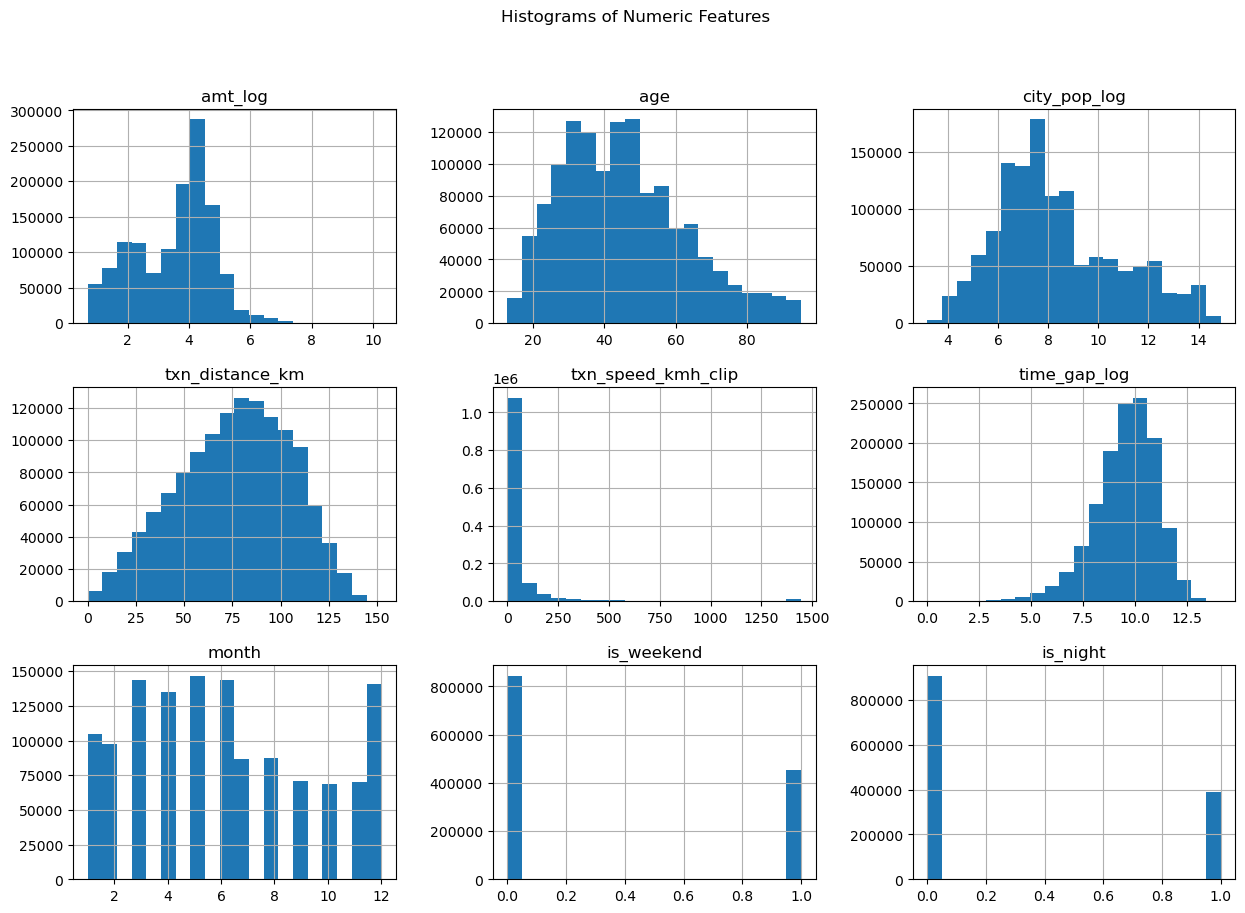

In [128]:
numeric_cols = [
    # Core continuous
    'amt_log', 'age', 'city_pop_log', 'txn_distance_km', 'txn_speed_kmh_clip', 'time_gap_log',
    # Semi-numeric (useful for pattern)
    'month', 'is_weekend', 'is_night'
]

fraudTrainC[numeric_cols].hist(bins=20, figsize=(15, 10))
plt.suptitle("Histograms of Numeric Features")

plt.show()

#### 5.2 Distribution of Categorical Vars

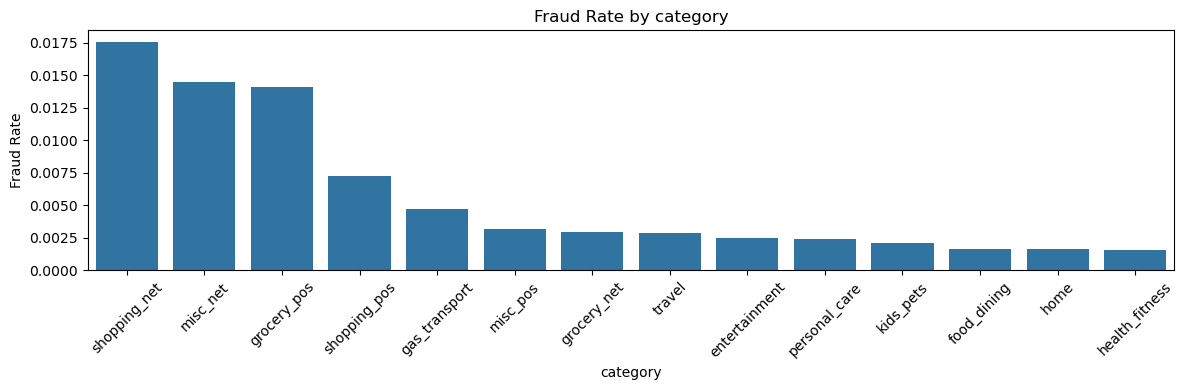

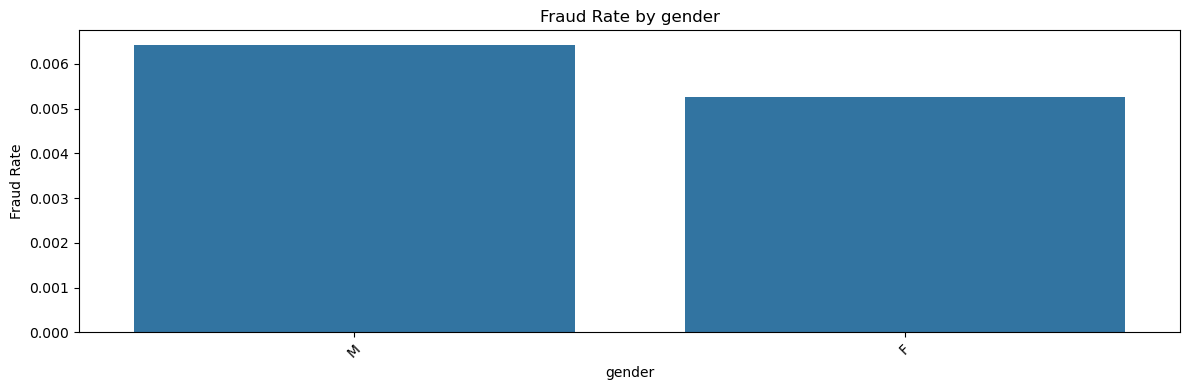

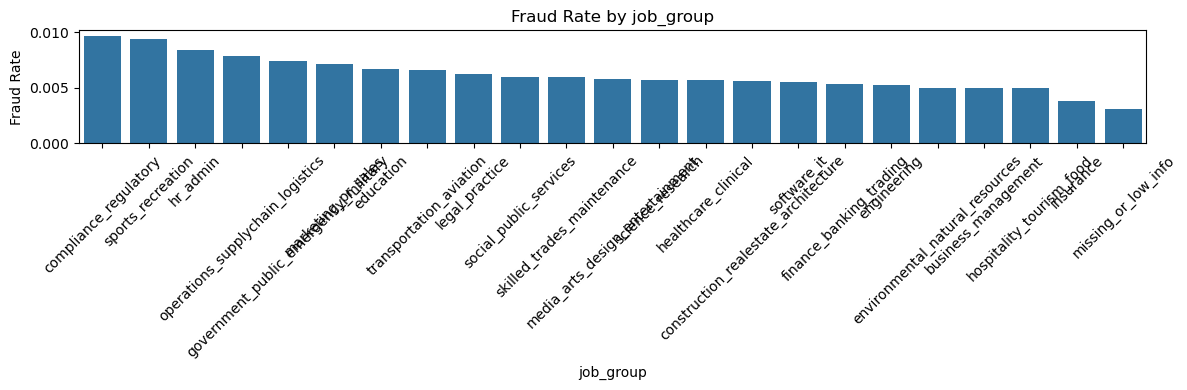

In [132]:
# categorical_cols = (
#     'category', 'gender', 'job_group'
# )

# for col in categorical_cols:
#     plt.figure(figsize=(16,4))
#     sns.countplot(x=col, data=fraudTrainC, order=fraudTrainC[col].value_counts().index)
#     plt.title(f"Distribution of {col}")
#     plt.xticks(rotation=45)
#     plt.tight_layout()

#     plt.show()

for col in categorical_cols:
    plt.figure(figsize=(12,4))
    
    fraud_rate = fraudTrainC.groupby(col)['is_fraud'].mean().sort_values(ascending=False)
    
    sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
    
    plt.title(f"Fraud Rate by {col}")
    plt.xticks(rotation=45)
    plt.ylabel("Fraud Rate")
    plt.tight_layout()
    
    plt.show()

#### 5.3 Categorical Variables vs Target (y)

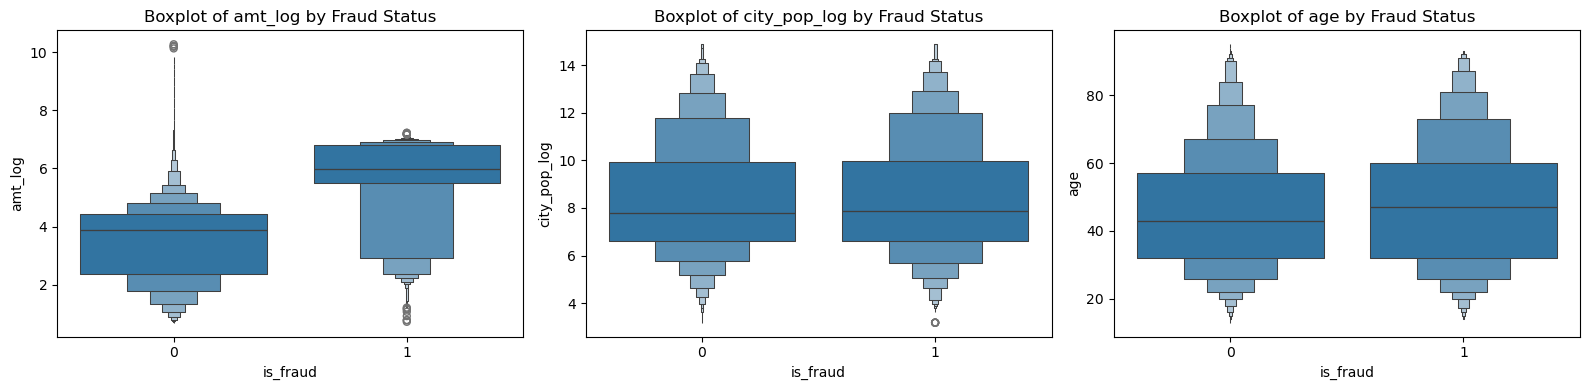

In [133]:
y = fraudTrainC['is_fraud']

numeric_cols = [ 'amt_log', 'city_pop_log', 'age' ]

fig, axes = plt.subplots(nrows=1, ncols=len(numeric_cols), figsize=(16, 4))

for i, col in enumerate(numeric_cols):
    sns.boxenplot(x='is_fraud', y=col, data=fraudTrainC, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col} by Fraud Status')

plt.tight_layout()
plt.show()

#### 5.4 Behavioral Analysis

Fraud vs Amount (log)

Text(0.5, 1.0, 'Fraud vs Non-Fraud Amount Distribution (Log Scale')

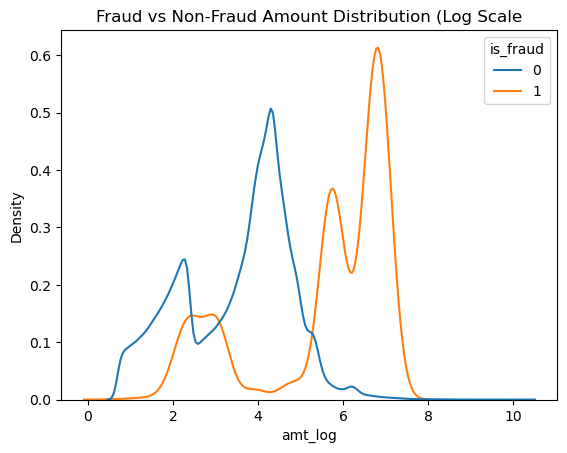

In [134]:
sns.kdeplot(
    data=fraudTrainC,
    x="amt_log",
    hue="is_fraud",
    common_norm=False
)

plt.title("Fraud vs Non-Fraud Amount Distribution (Log Scale)")

## 6. Modeling (XGBoost + Random Forest + CatBoost)

In [123]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

# ========================================================
# 0. Columns excluded from direct modeling
# ========================================================
# These columns are not used directly as model inputs:
# - raw timestamps / raw dates
# - raw coordinates already summarized into engineered features
# - raw identifier-like columns
# - raw columns replaced by transformed/log/cyclical versions
drop_from_model = [
    'trans_date_trans_time',
    'dob',
    'unix_time',
    'lat',
    'long',
    'merch_lat',
    'merch_long',
    'cc_num',
    'city',
    'state',
    'job',
    'amt',
    'city_pop',
    'hour',
    'dayofweek',
    'time_gap_sec',
    'time_gap_hr',
    'txn_speed_kmh',
    'Unnamed: 0'
]

# ========================================================
# 1. Feature groups for ablation study
# ========================================================
# V1: Baseline
# Keep the transformed / cleaned versions
base_features = [
    'amt_log',
    'city_pop_log',
    'age',
    'month',
    'is_weekend',
    'is_night',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos'
]

# V2: Behavioral
behavior_cols = [
    'txn_distance_km',
    'txn_speed_kmh_clip',
    'time_gap_log'
]

# V3: Risk features
risk_cols = [
    'job_risk_lvl',
    'spec_job_risk',
    'city_risk_lvl',
    'state_risk_lvl'
]

# Remove duplicates just in case
features_v1 = list(dict.fromkeys(base_features))
features_v2 = list(dict.fromkeys(base_features + behavior_cols))
features_v3 = list(dict.fromkeys(base_features + behavior_cols + risk_cols))

# ========================================================
# 2. Optional sanity checks
# ========================================================
# Check whether required columns exist in fraudTrainC before training
required_cols_static = list(dict.fromkeys(
    ['is_fraud', 'job_group', 'job', 'city', 'state'] + features_v2
))

missing_static = [c for c in required_cols_static if c not in fraudTrainC.columns]
if missing_static:
    raise ValueError(f"Missing required columns in fraudTrainC: {missing_static}")

## 6.1 Modeling (XGBoost + Random Forest + CatBoost)

In [124]:
from sklearn.model_selection import TimeSeriesSplit

# ========================================================
# 3. Initialize result storage
# ========================================================
stages = ['V1_Baseline', 'V2_Behavioral', 'V3_FullModel']
algorithms = ['XGB', 'RF', 'CAT']

results = {
    stage: {alg: {'roc': [], 'pr': []} for alg in algorithms}
    for stage in stages
}

# ========================================================
# 4. Time series rolling split
# ========================================================
tscv = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(fraudTrainC))

# ========================================================
# 5. Rolling CV + ablation study
# ========================================================
for fold, (train_idx, val_idx) in enumerate(splits, start=1):

    print(f"\n{'='*70}")
    print(f"STARTING FOLD {fold}")
    print(f"{'='*70}")

    # A. Physical split
    train_data = fraudTrainC.iloc[train_idx].copy()
    val_data = fraudTrainC.iloc[val_idx].copy()

    # --------------------------------------------------------
    # B. Dynamic feature engineering for risk features
    # These are calculated using TRAIN ONLY, then mapped to validation
    # --------------------------------------------------------

    # 1) Job Group Risk Mapping
    _, high_j, mod_j, safe_j = lift_risk_pipeline(
        train_data,
        group_col='job_group',
        target_col='is_fraud',
        high_min_count=500,
        high_min_lift=2.0,
        alpha=0.05,
        mod_min_count=1000,
        mod_min_lift=1.3,
        mod_max_lift=2.0,
        safe_min_count=1000,
        safe_max_lift=0.8
    )

    j_map = {j: 0 for j in train_data['job_group'].unique()}
    j_map.update({j: 2 for j in high_j['job_group']})
    j_map.update({j: 1 for j in mod_j['job_group']})
    j_map.update({j: -1 for j in safe_j['job_group']})

    train_data['job_risk_lvl'] = train_data['job_group'].map(j_map).fillna(0)
    val_data['job_risk_lvl'] = val_data['job_group'].map(j_map).fillna(0)

    # 2) Specific Job Risk (Sniper Mode)
    _, high_spec, _, _ = lift_risk_pipeline(
        train_data,
        group_col='job',
        target_col='is_fraud',
        high_min_count=500,
        high_min_lift=2.5,
        alpha=0.05
    )

    j_set = set(high_spec['job'])
    train_data['spec_job_risk'] = train_data['job'].apply(lambda x: 3 if x in j_set else 0)
    val_data['spec_job_risk'] = val_data['job'].apply(lambda x: 3 if x in j_set else 0)

    # 3) City Risk Mapping
    _, high_c, mod_c, safe_c = lift_risk_pipeline(
        train_data,
        group_col='city',
        target_col='is_fraud',
        high_min_count=1500,
        high_min_lift=2.0,
        alpha=0.05,
        mod_min_count=1000,
        mod_min_lift=1.3,
        mod_max_lift=2.0,
        safe_min_count=1000,
        safe_max_lift=0.8
    )

    c_map = {c: 0 for c in train_data['city'].unique()}
    c_map.update({c: 2 for c in high_c['city']})
    c_map.update({c: 1 for c in mod_c['city']})
    c_map.update({c: -1 for c in safe_c['city']})

    train_data['city_risk_lvl'] = train_data['city'].map(c_map).fillna(0)
    val_data['city_risk_lvl'] = val_data['city'].map(c_map).fillna(0)

    # 4) State Risk Mapping
    _, high_s, mod_s, safe_s = lift_risk_pipeline(
        train_data,
        group_col='state',
        target_col='is_fraud',
        high_min_count=2000,
        high_min_lift=1.5,
        alpha=0.05,
        mod_min_count=2000,
        mod_min_lift=1.2,
        mod_max_lift=1.5,
        safe_min_count=2000,
        safe_max_lift=0.9
    )

    s_map = {s: 0 for s in train_data['state'].unique()}
    s_map.update({s: 2 for s in high_s['state']})
    s_map.update({s: 1 for s in mod_s['state']})
    s_map.update({s: -1 for s in safe_s['state']})

    train_data['state_risk_lvl'] = train_data['state'].map(s_map).fillna(0)
    val_data['state_risk_lvl'] = val_data['state'].map(s_map).fillna(0)

    # --------------------------------------------------------
    # C. Experiment definitions
    # --------------------------------------------------------
    experiment_list = [
        ('V1_Baseline', features_v1),
        ('V2_Behavioral', features_v2),
        ('V3_FullModel', features_v3)
    ]

    # --------------------------------------------------------
    # D. Iterative experimentation
    # --------------------------------------------------------
    for stage_name, current_features in experiment_list:

        print(f"\n--- FOLD {fold} | {stage_name} ---")

        # Defensive checks
        missing_cols = [c for c in current_features if c not in train_data.columns]
        if missing_cols:
            raise ValueError(f"{stage_name} missing columns: {missing_cols}")

        # Prepare X/y
        X_train = train_data[current_features].copy().fillna(0)
        X_val = val_data[current_features].copy().fillna(0)
        y_train = train_data['is_fraud']
        y_val = val_data['is_fraud']

        # Check duplicate columns
        if X_train.columns.duplicated().any():
            dup_cols = X_train.columns[X_train.columns.duplicated()].tolist()
            raise ValueError(f"Duplicate columns found in {stage_name}: {dup_cols}")

        # Check dtypes
        # XGB / RF / this simple setup works best with numeric columns only
        non_numeric_cols = X_train.select_dtypes(include=['object', 'datetime']).columns.tolist()
        if non_numeric_cols:
            raise ValueError(
                f"{stage_name} contains non-numeric columns not yet encoded: {non_numeric_cols}"
            )

        # Positive class weight for imbalanced data
        pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

        # -------------------------
        # Model 1: XGBoost
        # -------------------------
        clf_xgb = XGBClassifier(
            n_estimators=100,
            scale_pos_weight=pos_weight,
            random_state=42,
            tree_method='hist',
            n_jobs=-1
        )
        clf_xgb.fit(X_train, y_train)
        y_prob_xgb = clf_xgb.predict_proba(X_val)[:, 1]

        # -------------------------
        # Model 2: Random Forest
        # -------------------------
        clf_rf = RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        )
        clf_rf.fit(X_train, y_train)
        y_prob_rf = clf_rf.predict_proba(X_val)[:, 1]

        # -------------------------
        # Model 3: CatBoost
        # -------------------------
        clf_cat = CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            scale_pos_weight=pos_weight,
            verbose=0,
            random_state=42,
            thread_count=-1
        )
        clf_cat.fit(X_train, y_train)
        y_prob_cat = clf_cat.predict_proba(X_val)[:, 1]

        # -------------------------
        # Evaluation
        # -------------------------
        eval_list = [
            ('XGB', y_prob_xgb),
            ('RF', y_prob_rf),
            ('CAT', y_prob_cat)
        ]

        for alg_name, prob in eval_list:
            roc = roc_auc_score(y_val, prob)
            pr = average_precision_score(y_val, prob)

            results[stage_name][alg_name]['roc'].append(roc)
            results[stage_name][alg_name]['pr'].append(pr)

            print(f"  [{alg_name:3}] ROC: {roc:.4f} | PR-AUC: {pr:.4f}")

        print()  # blank line between V1 / V2 / V3

# ========================================================
# 6. Mean performance summary
# ========================================================
print(f"\n{'='*70}")
print("MEAN PERFORMANCE SUMMARY")
print(f"{'='*70}")

for stage in stages:
    print(f"\n{stage}")
    for alg in algorithms:
        mean_roc = np.mean(results[stage][alg]['roc'])
        mean_pr = np.mean(results[stage][alg]['pr'])
        print(f"  [{alg:3}] Mean ROC: {mean_roc:.4f} | Mean PR-AUC: {mean_pr:.4f}")


STARTING FOLD 1

--- FOLD 1 | V1_Baseline ---
  [XGB] ROC: 0.9613 | PR-AUC: 0.3444
  [RF ] ROC: 0.9362 | PR-AUC: 0.5919
  [CAT] ROC: 0.9795 | PR-AUC: 0.5392


--- FOLD 1 | V2_Behavioral ---
  [XGB] ROC: 0.9740 | PR-AUC: 0.5445
  [RF ] ROC: 0.9555 | PR-AUC: 0.6307
  [CAT] ROC: 0.9850 | PR-AUC: 0.6460


--- FOLD 1 | V3_FullModel ---
  [XGB] ROC: 0.9708 | PR-AUC: 0.4678
  [RF ] ROC: 0.9453 | PR-AUC: 0.5747
  [CAT] ROC: 0.9776 | PR-AUC: 0.5703


STARTING FOLD 2

--- FOLD 2 | V1_Baseline ---
  [XGB] ROC: 0.9626 | PR-AUC: 0.3833
  [RF ] ROC: 0.9239 | PR-AUC: 0.5872
  [CAT] ROC: 0.9806 | PR-AUC: 0.5549


--- FOLD 2 | V2_Behavioral ---
  [XGB] ROC: 0.9817 | PR-AUC: 0.5593
  [RF ] ROC: 0.9405 | PR-AUC: 0.6299
  [CAT] ROC: 0.9863 | PR-AUC: 0.6425


--- FOLD 2 | V3_FullModel ---
  [XGB] ROC: 0.9599 | PR-AUC: 0.4925
  [RF ] ROC: 0.9281 | PR-AUC: 0.5795
  [CAT] ROC: 0.9759 | PR-AUC: 0.5767


STARTING FOLD 3

--- FOLD 3 | V1_Baseline ---
  [XGB] ROC: 0.9600 | PR-AUC: 0.3124
  [RF ] ROC: 0.9484 | PR

## 4.5 🚀 Why we selected V2_Behavioral as the final model

### 1. V2: Behavioral Features

These are added on top of V1:

- `txn_distance_km`
- `txn_speed_kmh_clip`
- `time_gap_log`

---

### 2. We prioritize PR-AUC (not ROC-AUC)

This is a **fraud detection problem → highly imbalanced dataset**.

- Fraud rate is extremely low  
- ROC-AUC can look high even if the model is not actually catching fraud well  

**PR-AUC reflects real business value:**

> “Among the transactions flagged as risky, how many are actually fraud?”

👉 Therefore:

**Model selection is primarily based on PR-AUC**

---

### ✅ Key Observations

#### 🔹 1. V2 consistently outperforms V1 across all models

Example:

- XGB: 0.417 → 0.596  
- RF: 0.617 → 0.671  
- CAT: 0.576 → 0.677  

👉 **Interpretation:**

Adding behavioral features significantly improves fraud detection.

---

#### 🔹 2. V2 is the most stable across folds

Look at V2 CAT:

- Fold 1: 0.646  
- Fold 2: 0.642  
- Fold 3: 0.658  
- Fold 4: 0.724  
- Fold 5: 0.715  

👉 **Consistent + strong = good generalization**

---

### 🧠 Key Insight

> Fraud detection is primarily driven by **behavioral anomalies** rather than static demographic or aggregated risk features.

---

### ⚖️ Why V3 underperformed

Even though V3 adds more features, performance drops because:

#### ❌ 1. Risk features are too coarse

- `job_group`, `city`, `state`  
- Not transaction-specific  
- Weak signal compared to behavioral features  

---

#### ❌ 2. Time instability (VERY IMPORTANT)

A “high-risk job” in training  
≠ still high-risk in validation  

👉 Causes **poor generalization**

---

#### ❌ 3. Signal dilution

- Strong signals (behavior) get mixed with weak/noisy signals  
- Tree models may split on suboptimal features

---

### 🏁 Final Model Choice

👉 V2_Behavioral + CatBoost

Why?

- Highest PR-AUC (most important metric)
- Consistent across folds
- Strong generalization
- Behavior-driven features align with fraud mechanism

🤖 Model Comparison (XGB vs RF vs CAT)
🔷 1. XGBoost
👍 Strengths
Very high ROC-AUC (best ranking ability)
Learns complex interactions
👎 Weaknesses
Lower PR-AUC → weaker at identifying rare fraud cases

👉 Interpretation:

Good at ranking, but not optimal for rare-event precision

🌲 2. Random Forest
👍 Strengths
Strong PR-AUC (especially in V1 & V2)
Very stable across folds
Robust to noise
👎 Weaknesses
Slightly lower ROC
Less powerful than boosting methods

👉 Interpretation:

Very reliable baseline model for fraud detection

🐱 3. CatBoost (BEST)
👍 Strengths
Highest PR-AUC (0.6774) in V2
Highest ROC overall
Most consistent performance
Handles feature interactions very well
👎 Weaknesses
Slightly more complex / slower
Not always dramatically better than RF (but still best overall)

👉 Interpretation:

Best balance of ranking + fraud detection precision